In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../')
sys.path.append('../../external/hovernet')
sys.path.append('../../hedest')

import json
import os
import pickle
import torch
import scanpy as sc

PATH = '/home/luca/Documents/data/'

#'/cluster/CBIO/data1/lgortana/'
#'/home/luca/Documents/data/'

# Load data

In [2]:
# names
adata_name = 'CytAssist_11mm_FFPE_Human_Ovarian_Carcinoma'
sim_tag = "6_moco_clusters_200spots_balanced_15mean_15var"
model_tag = "model_default_hidden_dim_512-256_norm_True_dropout_0.0_alpha_0.0_lr_0.0001_divergence_l2_beta_0.0_seed_0"

In [ ]:
import pandas as pd

data_path = os.path.join(PATH, adata_name)
sim_path = os.path.join(data_path, "sim")

#load image_dict
image_dict = torch.load(os.path.join(sim_path, f'{sim_tag}_image_dict_64px_20um.pt'))

#load ground truth
ground_truth = pd.read_csv(os.path.join(sim_path, f'{sim_tag}_gt.csv'), index_col=0)
ground_truth.index = ground_truth.index.astype(str)

In [ ]:
#load model infos
model_dir = os.path.join(f'../../models/simulations/full_sim/{sim_tag}_blurr/perturb_0', model_tag)

with open(os.path.join(model_dir, 'info.pickle'), 'rb') as f:
    model_info = pickle.load(f)

# Analysis

In [211]:
from hedest.analysis.pred_analyzer import PredAnalyzer

analyzer = PredAnalyzer(model_info=model_info,
                        adjusted=True,
                        ground_truth=ground_truth, 
                        image_dict=image_dict
                        )

Loading predicted labels...
Loading true labels...
Use `add_attributes(seg_dict=your_seg_dict)` to add one.


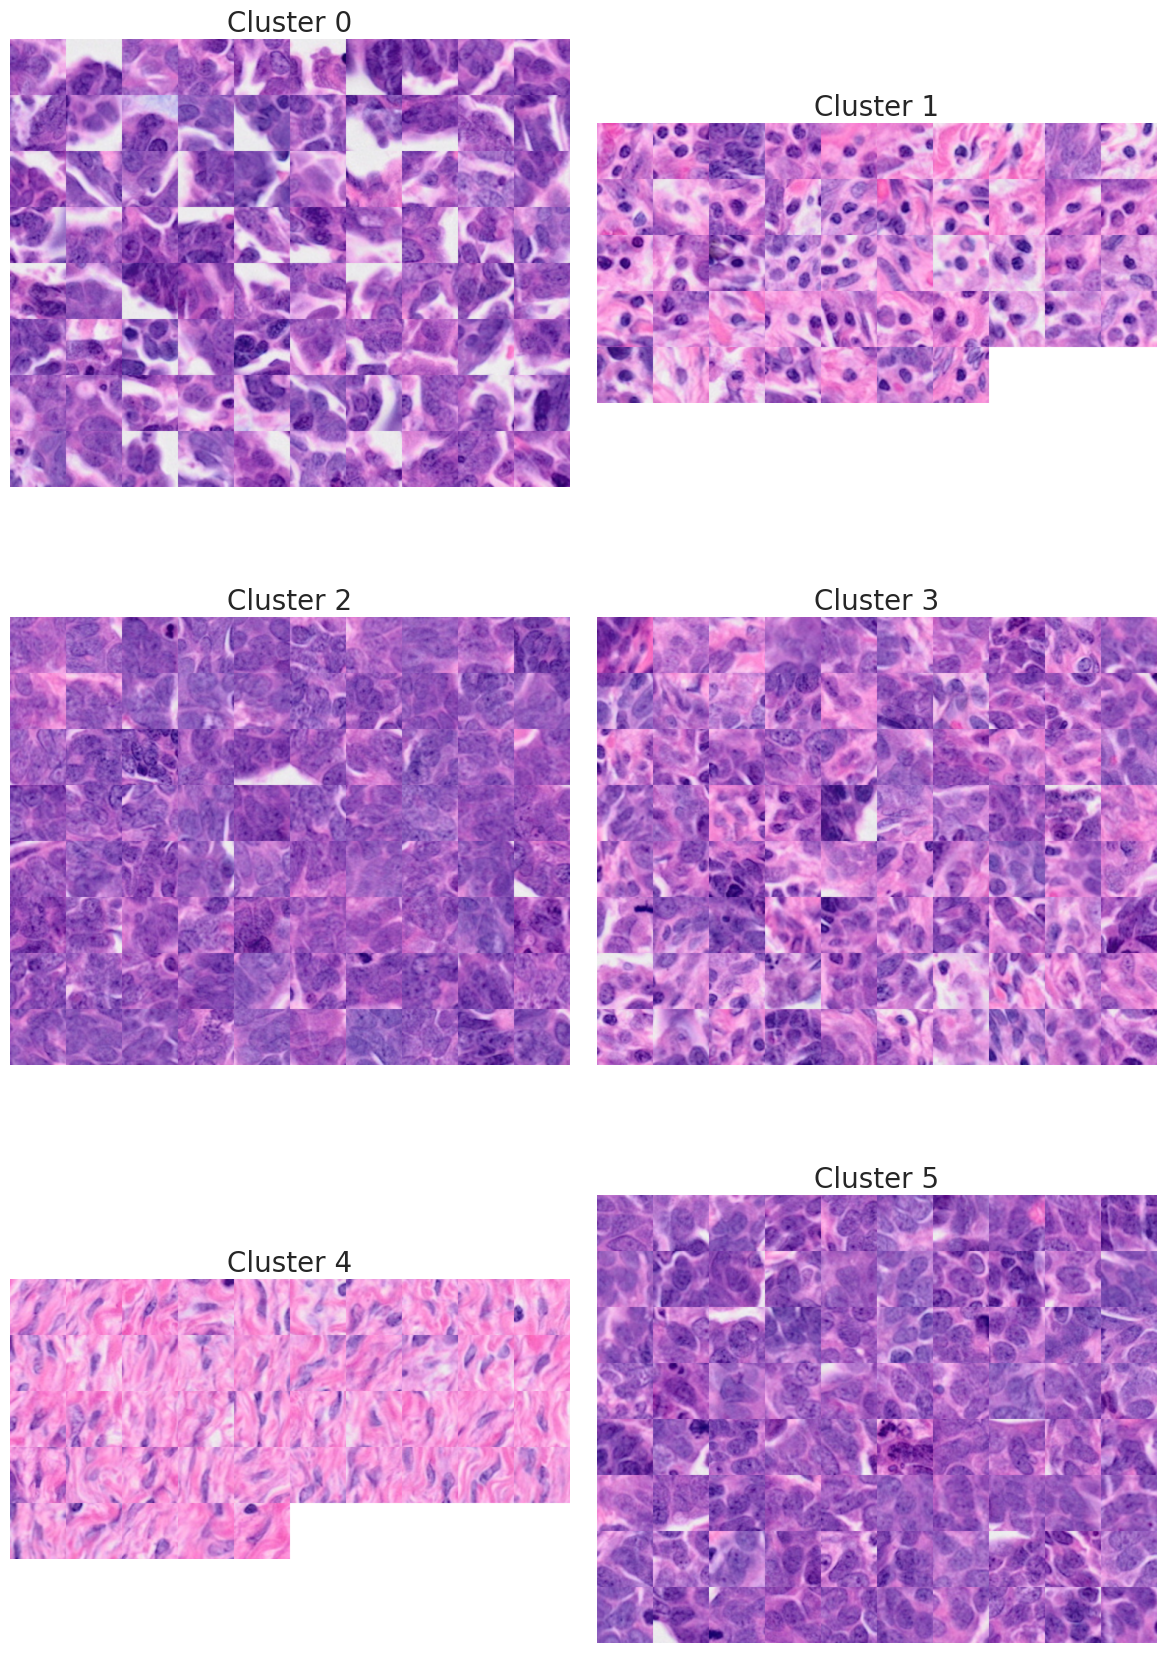

In [ ]:
analyzer.plot_grid_celltype(n = 80, selection = 'random', show_probs=False, display=False)
# fig.savefig("figures/grid_celltype_imbalanced.svg", format="svg", dpi=300, bbox_inches="tight")

In [195]:
cm = analyzer.evaluate_cell_predictions()['Confusion Matrix']

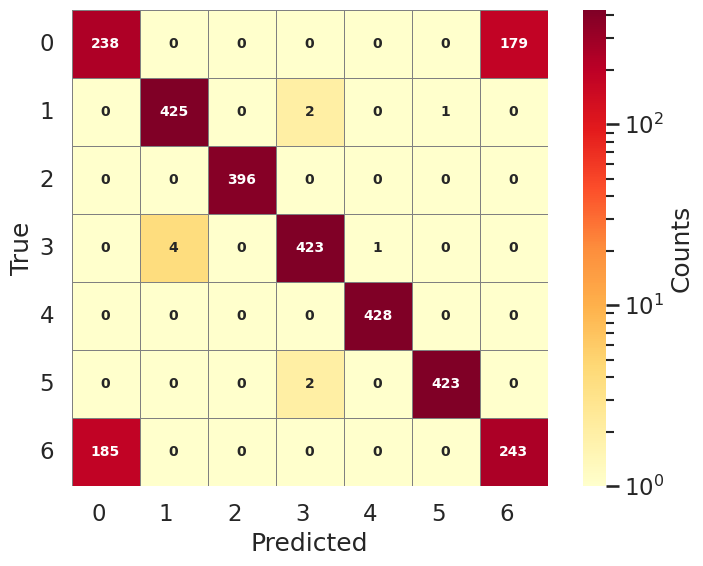

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

cm_clean = cm.copy()
cm_clean.index = [label.replace("Cluster ", "") for label in cm.index]
cm_clean.columns = [label.replace("Cluster ", "") for label in cm.columns]

# Replace zeros for LogNorm (optional, only for coloring)
cm_plot = cm_clean.replace(0, 1)

sns.set_context("talk")
sns.set_style("white")

cm_norm = cm_clean.div(cm_clean.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))

cmap = sns.color_palette("YlOrRd", as_cmap=True)

# Heatmap with logarithmic color scale
ax = sns.heatmap(
    cm_plot,                # used for coloring (zeros replaced)
    cmap=cmap,
    annot=cm_clean,         # show original values
    fmt="d",
    annot_kws={"fontsize": 10, "fontweight": "bold"},
    cbar_kws={"label": "Counts"},
    square=True,
    linewidths=0.5,
    linecolor='gray',
    norm=LogNorm()          # <-- logarithmic scale for colors
)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")

plt.xticks(rotation=0, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
# plt.savefig("figures/confusion_matrix_noadj_balanced.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()